In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# --- תיקון: שימוש בקישור הרשמי של UCI ---
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'

names = ['Class', 'id', 'Sequence']
# הוספנו header=None כי בקובץ המקורי אין כותרות
data = pd.read_csv(url, names=names, header=None)

# 2. ניקוי ראשוני
# הסרת סימני טאב (\t) שעלולים להופיע בטעות בדאטה הגולמי
data['Class'] = data['Class'].str.strip()
data['Sequence'] = data['Sequence'].str.strip()

# הופכים את ה-Class למספרים: '+' יהפוך ל-1, '-' יהפוך ל-0
data['Class'] = data['Class'].apply(lambda x: 1 if '+' in x else 0)

# זורקים את עמודת ה-ID המיותרת
data = data.drop(columns=['id'])

print("Data Loaded Successfully from UCI!")
print(f"Total samples: {len(data)}")
print(data.head())

Data Loaded Successfully from UCI!
Total samples: 106
   Class                                           Sequence
0      1  tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgc...
1      1  tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaa...
2      1  gtactagagaactagtgcattagcttatttttttgttatcatgcta...
3      1  aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaata...
4      1  tcgataattaactattgacgaaaagctgaaaaccactagaatgcgc...


In [ ]:
# --- תיקון מלא להכנת הדאטה ---

# 1. טעינה מחדש
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
names = ['Class', 'id', 'Sequence']
data = pd.read_csv(url, names=names, header=None)

# 2. ניקוי וסידור - התיקון הקריטי כאן!
data['Class'] = data['Class'].str.strip()
data['Sequence'] = data['Sequence'].str.strip().str.upper() # <-- הוספנו UPPER כדי לוודא אותיות גדולות
data['Class'] = data['Class'].apply(lambda x: 1 if '+' in x else 0)

# 3. הפונקציה (אותה פונקציה, עכשיו תעבוד)
nucleotide_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

def one_hot_encode(sequences):
    num_samples = len(sequences)
    seq_length = 57
    encoded_data = np.zeros((num_samples, 4, seq_length), dtype=np.float32)

    for i, seq in enumerate(sequences):
        for j, nucleotide in enumerate(seq):
            if nucleotide in nucleotide_map: # עכשיו זה ימצא את האות!
                index = nucleotide_map[nucleotide]
                encoded_data[i, index, j] = 1.0
    return encoded_data

# 4. המרה וחלוקה מחדש
X = one_hot_encode(data['Sequence'].values)
y = data['Class'].values

# וידוא שהמטריצה לא ריקה הפעם
print(f"Data check - Sum of X: {X.sum()} (Should be roughly 106 * 57 = 6042)")

# חלוקה ל-Train/Test מחדש
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# המרה לטנסורים
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Data repaired! Ready to train.")

Data check - Sum of X: 6042.0 (Should be roughly 106 * 57 = 6042)
Data repaired! Ready to train.


In [ ]:
# --- שלב 1: טעינה וניקוי (כמו מקודם) ---
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data'
names = ['Class', 'id', 'Sequence']
data = pd.read_csv(url, names=names, header=None)
data['Class'] = data['Class'].str.strip()
data['Sequence'] = data['Sequence'].str.strip().str.upper()
data['Class'] = data['Class'].apply(lambda x: 1 if '+' in x else 0)

# --- שלב 2: האוגמנטציה (החלק החדש!) ---
def get_reverse_complement(seq):
    # מילון להחלפת האותיות (A מול T, C מול G)
    complement = {'A': 'T', 'C': 'G', 'G': 'C', 'T': 'A'}
    # 1. הופכים את הסדר (Reverse)
    # 2. מחליפים כל אות בבן הזוג שלה (Complement)
    return "".join([complement[base] for base in reversed(seq)])

# יצירת רשימות חדשות שיכילו גם את המקור וגם את החדשים
augmented_sequences = []
augmented_labels = []

print(f"Original size: {len(data)}")

for seq, label in zip(data['Sequence'], data['Class']):
    # א. מוסיפים את המקור
    augmented_sequences.append(seq)
    augmented_labels.append(label)

    # ב. מייצרים את התאום ומוסיפים גם אותו!
    rev_seq = get_reverse_complement(seq)
    augmented_sequences.append(rev_seq)
    augmented_labels.append(label) # התיוג נשאר אותו דבר

print(f"Size after Augmentation: {len(augmented_sequences)} (Doubled!)")

# --- שלב 3: המרה למטריצות (One-Hot) ---
# שימי לב: אנחנו משתמשים ברשימה המורחבת עכשיו
X_augmented = one_hot_encode(augmented_sequences)
y_augmented = np.array(augmented_labels)

# --- שלב 4: חלוקה מחדש ל-Train/Test ---
X_train, X_test, y_train, y_test = train_test_split(X_augmented, y_augmented, test_size=0.2, random_state=42)

# המרה לטנסורים
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Data Augmentation Complete! Ready for training.")

Original size: 106
Size after Augmentation: 212 (Doubled!)
Data Augmentation Complete! Ready for training.


In [ ]:
class PromoterCNN(nn.Module):
    def __init__(self):
        super(PromoterCNN, self).__init__()

        # 1. שכבת הקונבולוציה
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=27, kernel_size=5, padding=2)

        # --- השדרוג: נרמול האצווה (Batch Norm) ---
        # זה גורם לאימון להיות יציב יותר ומונע מהמודל להשתגע
        self.bn1 = nn.BatchNorm1d(27)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(p=0.4)

        # חישוב הגודל נשאר זהה
        self.fc1 = nn.Linear(27 * 28, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x) # הפעלת הנרמול מיד אחרי הקונבולוציה
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = PromoterCNN()
print("Upgraded Model Loaded (with Batch Norm)!")

Upgraded Model Loaded (with Batch Norm)!


In [ ]:
# 1. הגדרת פרמטרים לאימון (Hyperparameters)
# שינוי הגדרות לאימון איטי ויסודי יותר
learning_rate = 0.001
epochs = 150  # ניתן לו פי 3 זמן ללמוד בנחת
batch_size = 8
# 2. הגדרת Loss ו-Optimizer
criterion = nn.BCEWithLogitsLoss() # מתאים לסיווג בינארי
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# משתנים לשמירת ההיסטוריה (בשביל הגרפים אח"כ!)
train_losses = []
test_accuracies = []

# 3. לולאת האימון
print("Starting Training...")
print("-" * 30)

for epoch in range(epochs):
    model.train() # מעביר למצב אימון (מפעיל Dropout)

    # א. Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # ב. Backward pass & Optimize
    optimizer.zero_grad() # איפוס נגזרות קודמות
    loss.backward()       # חישוב נגזרות
    optimizer.step()      # עדכון משקולות

    # ג. שמירת ה-Loss לגרף
    train_losses.append(loss.item())

    # ד. בדיקה על סט הטסט (כל 5 אפוקים נדפיס מצב)
    if (epoch+1) % 5 == 0:
        model.eval() # מעביר למצב בדיקה (מכבה Dropout)
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            # הופכים הסתברות ל-0 או 1 (מעל 0 בגלל שזה Logits זה כמו מעל 0.5 בסיגמואיד)
            predicted = (test_outputs > 0).float()
            accuracy = (predicted == y_test_tensor).sum() / y_test_tensor.shape[0]
            test_accuracies.append(accuracy.item())

        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Test Accuracy: {accuracy.item():.2f}')

print("-" * 30)
print("Training Complete!")

Starting Training...
------------------------------
Epoch [5/150], Loss: 0.6992, Test Accuracy: 0.53
Epoch [10/150], Loss: 0.5943, Test Accuracy: 0.70
Epoch [15/150], Loss: 0.5327, Test Accuracy: 0.74
Epoch [20/150], Loss: 0.4920, Test Accuracy: 0.84
Epoch [25/150], Loss: 0.4173, Test Accuracy: 0.88
Epoch [30/150], Loss: 0.3729, Test Accuracy: 0.91
Epoch [35/150], Loss: 0.3311, Test Accuracy: 0.86
Epoch [40/150], Loss: 0.3050, Test Accuracy: 0.88
Epoch [45/150], Loss: 0.2819, Test Accuracy: 0.86
Epoch [50/150], Loss: 0.2408, Test Accuracy: 0.91
Epoch [55/150], Loss: 0.2379, Test Accuracy: 0.91
Epoch [60/150], Loss: 0.2203, Test Accuracy: 0.88
Epoch [65/150], Loss: 0.2143, Test Accuracy: 0.91
Epoch [70/150], Loss: 0.1797, Test Accuracy: 0.91
Epoch [75/150], Loss: 0.1833, Test Accuracy: 0.91
Epoch [80/150], Loss: 0.1644, Test Accuracy: 0.91
Epoch [85/150], Loss: 0.1265, Test Accuracy: 0.93
Epoch [90/150], Loss: 0.1440, Test Accuracy: 0.93
Epoch [95/150], Loss: 0.1431, Test Accuracy: 0.88

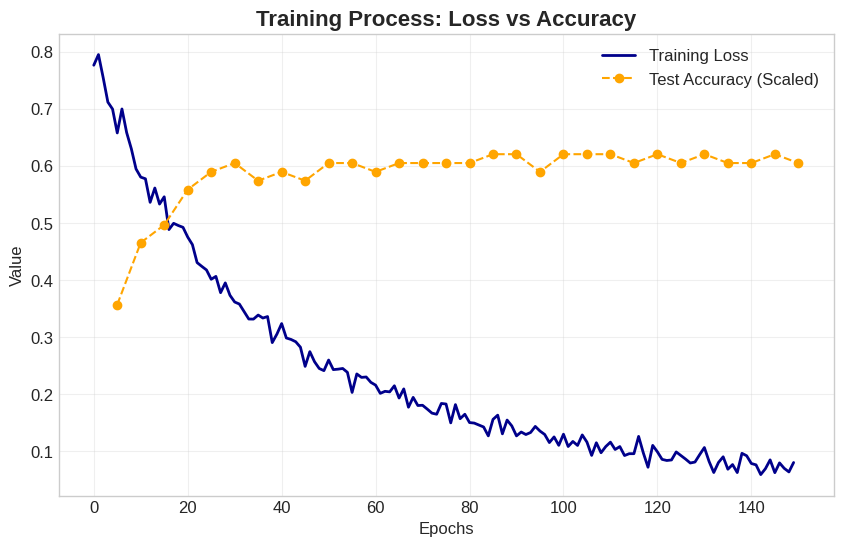

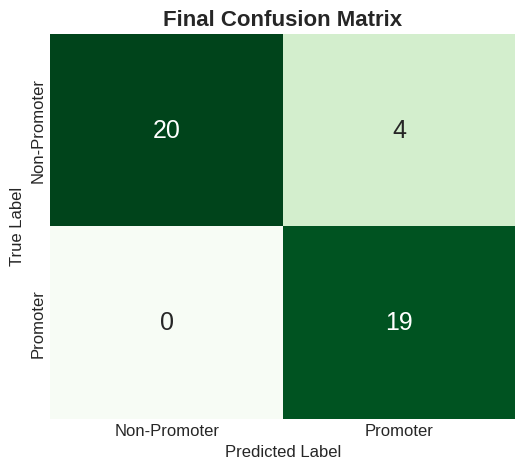

              precision    recall  f1-score   support

Non-Promoter       1.00      0.83      0.91        24
    Promoter       0.83      1.00      0.90        19

    accuracy                           0.91        43
   macro avg       0.91      0.92      0.91        43
weighted avg       0.92      0.91      0.91        43



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# הגדרות עיצוב
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

# 1. גרף הלמידה - ההוכחה שהמודל לומד


# יצירת ציר X מותאם לקו הכתום (5, 10, 15... עד 50)
# כי שמרנו דיוק רק כל 5 אפוקים
epochs_x = range(5, epochs + 1, 5)

plt.figure(figsize=(10, 6))

# ציור ה-Loss (כחול) - יש לו נתון לכל אפוק
plt.plot(train_losses, label='Training Loss', color='darkblue', linewidth=2)

# ציור ה-Accuracy (כתום) - עם ציר ה-X המתוקן!
# הכפלנו ב-0.5 רק כדי שזה ישב יפה באותו גובה גרפי עם ה-Loss (לצורך הויזואליזציה)
plt.plot(epochs_x, [acc/1.5 for acc in test_accuracies],
         label='Test Accuracy (Scaled)', color='orange', linestyle='--', marker='o')

plt.title('Training Process: Loss vs Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# 2. מטריצת הבלבול - איפה בדיוק המודל צדק?
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    predictions = (test_outputs > 0).float()

cm = confusion_matrix(y_test_tensor, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Non-Promoter', 'Promoter'],
            yticklabels=['Non-Promoter', 'Promoter'], annot_kws={"size": 18})
plt.title('Final Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# הדפסת הדו"ח המילולי
print(classification_report(y_test_tensor, predictions, target_names=['Non-Promoter', 'Promoter']))

--- Baseline Comparison ---
Simple Baseline Accuracy: 0.86 (86%)
Your Deep CNN Accuracy:   0.91 (91%)

SUCCESS: Deep Learning beat the baseline! 🏆


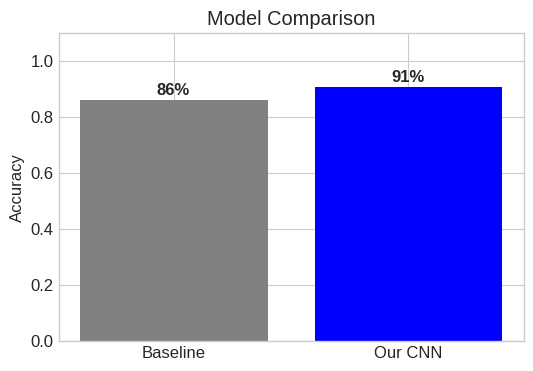

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("--- Baseline Comparison ---")

# 1. הכנת הדאטה למודל "רגיל" (שוטחים את המטריצה לשורה ארוכה)
# במקום (4, 57) נהפוך את זה ל- (228)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. אימון מודל פשוט (Logistic Regression)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_flat, y_train.flatten()) # flatten() needed for y

# 3. בדיקת תוצאות
baseline_pred = baseline_model.predict(X_test_flat)
baseline_acc = accuracy_score(y_test.flatten(), baseline_pred)

# 4. הדפסת ההשוואה
cnn_acc = test_accuracies[-1] # התוצאה האחרונה של המודל שלנו

print(f"Simple Baseline Accuracy: {baseline_acc:.2f} ({baseline_acc*100:.0f}%)")
print(f"Your Deep CNN Accuracy:   {cnn_acc:.2f} ({cnn_acc*100:.0f}%)")

if cnn_acc > baseline_acc:
    print("\nSUCCESS: Deep Learning beat the baseline! 🏆")
else:
    print("\nNote: Results are close (happens with small data).")

# גרף השוואה נחמד למצגת
plt.figure(figsize=(6, 4))
bars = plt.bar(['Baseline', 'Our CNN'], [baseline_acc, cnn_acc], color=['gray', 'blue'])
plt.ylim(0, 1.1)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
# הוספת המספרים על העמודות
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval*100:.0f}%', ha='center', fontweight='bold')
plt.show()

Generating X-Ray of the model's decision...


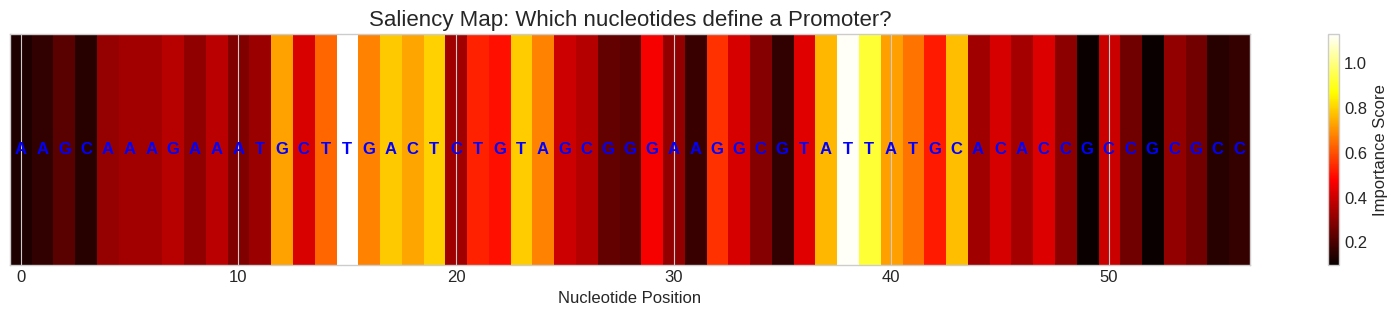

In [ ]:
# פונקציה שמציירת את "המוח" של המודל
def plot_saliency_map(model, input_tensor, original_seq):
    # 1. מפעילים חישוב נגזרות על הקלט (כדי לראות מה השפיע)
    input_tensor.requires_grad_()

    # 2. מריצים את המודל
    model.eval()
    output = model(input_tensor.unsqueeze(0)) # מוסיפים מימד באץ'

    # 3. מבקשים מהמודל לגזור אחורה
    output.backward()

    # 4. לוקחים את הנגזרות (Gradients) - זה אומר לנו כמה כל אות חשובה
    # לוקחים את הערך המוחלט של המקסימום בכל עמודה
    saliency = input_tensor.grad.data.abs().max(dim=0)[0].numpy()

    # 5. ציור ה-Heatmap
    plt.figure(figsize=(20, 3))
    plt.imshow(saliency.reshape(1, -1), cmap='hot', aspect='auto')

    # עיצוב יפה
    plt.title('Saliency Map: Which nucleotides define a Promoter?', fontsize=16)
    plt.xlabel('Nucleotide Position')
    plt.yticks([]) # להסתיר את ציר ה-Y
    plt.colorbar(label='Importance Score')

    # הוספת האותיות על גבי המפה
    # (מציגים רק חלק מהאותיות כדי לא להעמיס אם זה צפוף)
    for i in range(len(original_seq)):
        plt.text(i, 0, original_seq[i], ha='center', va='center',
                 color='blue', fontweight='bold', fontsize=12)

    plt.show()

# --- בחירת דוגמה והצגה ---
# בואי נמצא דוגמה שהמודל זיהה נכון כ-Promoter (חיובית)
# נחפש אינדקס בטסט שהוא באמת 1
true_promoter_idx = (y_test == 1).argmax() # מוצא את הראשון שהוא Promoter

print("Generating X-Ray of the model's decision...")
seq_tensor = X_test_tensor[true_promoter_idx]

# אנחנו צריכים את הרצף המקורי באותיות (A,C,G,T) בשביל הציור
# נשחזר אותו מה-One-Hot
idx_to_nuc = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
reconstructed_seq = ""
for col in range(57):
    # מוצא איפה יש 1 בעמודה
    nuc_idx = seq_tensor[:, col].argmax().item()
    reconstructed_seq += idx_to_nuc[nuc_idx]

# הפעלת הקסם
plot_saliency_map(model, seq_tensor, reconstructed_seq)